In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cycler

import urllib, base64
import requests
import io
import os

from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.fits import DE_fit, TRF_fit, MCMC_fit
from pyLIMA.models import PSPL_model


import pyLIMA.fits.objective_functions as pfof
from pyLIMA.outputs.pyLIMA_plots import create_telescopes_to_plot_model
import pyLIMA.outputs.pyLIMA_plots as plplots

from pyLIMA.toolbox import fake_telescopes, plots
from pyLIMA import toolbox as ptool

In [2]:
name = 'Gaia19dke'
ra, dec = 291.49451, 28.40686

In [3]:
data_gsa = np.loadtxt("Gaia19dke_GSA_G.dat")

data_lco_g = np.loadtxt("Gaia19dke_LCO_g.dat")
data_lco_r = np.loadtxt("Gaia19dke_LCO_r.dat")
data_lco_i = np.loadtxt("Gaia19dke_LCO_i.dat")

data_ztf_g = np.loadtxt("Gaia19dke_ZTF_g.dat")
data_ztf_r = np.loadtxt("Gaia19dke_ZTF_r.dat")
data_ztf_i = np.loadtxt("Gaia19dke_ZTF_i.dat")

In [4]:
gaia_event = event.Event(ra=ra, dec=dec)
# gaia_event = event.Event()
gaia_event.name = name
# gaia_event.ra, gaia_event.dec = ra, dec
# gaia_event.North_East_vectors()

In [5]:
telescope_gsa = telescopes.Telescope(name='Gaia',
                                      camera_filter='G',
                                      light_curve=data_gsa,
                                      light_curve_names=['time', 'mag', 'err_mag'],
                                      light_curve_units=['JD', 'mag', 'err_mag'],
                                     # location='Earth')#,
                                      location='Space', spacecraft_name='Gaia')
gaia_event.telescopes.append(telescope_gsa)

telescope_lco_g = telescopes.Telescope(name='LCO_1m_gp',
                                      camera_filter='g',
                                      light_curve=data_lco_g,
                                      light_curve_names=['time', 'mag', 'err_mag'],
                                      light_curve_units=['JD', 'mag', 'err_mag'],
                                      location='Earth')
gaia_event.telescopes.append(telescope_lco_g)

# telescope_lco_r = telescopes.Telescope(name='LCO_1m_rp',
#                                       camera_filter='r',
#                                       light_curve=data_lco_r,
#                                       light_curve_names=['time', 'mag', 'err_mag'],
#                                       light_curve_units=['JD', 'mag', 'err_mag'],
#                                       location='Earth')
# gaia_event.telescopes.append(telescope_lco_r)

telescope_lco_i = telescopes.Telescope(name='LCO_1m_ip',
                                      camera_filter='i',
                                      light_curve=data_lco_i,
                                      light_curve_names=['time', 'mag', 'err_mag'],
                                      light_curve_units=['JD', 'mag', 'err_mag'],
                                      location='Earth')
gaia_event.telescopes.append(telescope_lco_i)

telescope_ztf_g = telescopes.Telescope(name='ZTF_g',
                                      camera_filter='g',
                                      light_curve=data_ztf_g,
                                      light_curve_names=['time', 'mag', 'err_mag'],
                                      light_curve_units=['JD', 'mag', 'err_mag'],
                                      location='Earth')
gaia_event.telescopes.append(telescope_ztf_g)

telescope_ztf_r = telescopes.Telescope(name='ZTF_r',
                                      camera_filter='r',
                                      light_curve=data_ztf_r,
                                      light_curve_names=['time', 'mag', 'err_mag'],
                                      light_curve_units=['JD', 'mag', 'err_mag'],
                                      location='Earth')
gaia_event.telescopes.append(telescope_ztf_r)

telescope_ztf_i = telescopes.Telescope(name='ZTF_i',
                                      camera_filter='i',
                                      light_curve=data_ztf_i,
                                      light_curve_names=['time', 'mag', 'err_mag'],
                                      light_curve_units=['JD', 'mag', 'err_mag'],
                                      location='Earth')
gaia_event.telescopes.append(telescope_ztf_i)

pyLIMA found (and eliminate) some bad_data for telescope LCO_1m_gp, please check your_telescope.bad_data
pyLIMA found (and eliminate) some bad_data for telescope LCO_1m_ip, please check your_telescope.bad_data
pyLIMA found (and eliminate) some bad_data for telescope ZTF_g, please check your_telescope.bad_data
pyLIMA found (and eliminate) some bad_data for telescope ZTF_r, please check your_telescope.bad_data


In [6]:
gaia_event.find_survey('Gaia')
gaia_event.check_event()

check_event  : Everything looks fine...


In [7]:
pspl_no_par = PSPL_model.PSPLmodel(gaia_event, parallax=['None', 0.])
pspl = PSPL_model.PSPLmodel(gaia_event, parallax=['Full', 2459058.])

fit_init = DE_fit.DEfit(pspl_no_par)
# fit_par = MCMC_fit.MCMCfit(pspl)
# fit_par = TRF_fit.TRFfit(pspl)
fit_par = DE_fit.DEfit(pspl)

fit_init.fit_parameters["u0"][1] = [0., 2.0]
fit_init.fit_parameters["tE"][1] = [0., 1000.]

fit_par.model_parameters_guess = [2459063.50, -0.598, 164.9, -0.0895, -0.1891]

fit_par.fit_parameters["u0"][1] = [-2.0, 0.0]
fit_par.fit_parameters["tE"][1] = [0., 1000.]
fit_par.fit_parameters["piEN"][1] = [-2.0, 0.0]
fit_par.fit_parameters["piEE"][1] = [-2.0, 0.0]

fit_init.fit()
fit_par.fit()

Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Gaia: SUCCESS
Parallax(Full) estimated for the telescope LCO_1m_gp: SUCCESS
Parallax(Full) estimated for the telescope LCO_1m_ip: SUCCESS
Parallax(Full) estimated for the telescope ZTF_g: SUCCESS
Parallax(Full) estimated for the telescope ZTF_r: SUCCESS
Parallax(Full) estimated for the telescope ZTF_i: SUCCESS
DE converge to objective function : f(x) =  34352.57176026639
DE converge to parameters : =  ['2459062.6586223664' '0.41459919834528447' '499.99366774760864']
fit  : Differential Evolution fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2459062.6586223664)),
             ('u0', np.float64(0.41459919834528447)),
             ('tE', np.float64(499.99366774760864)),
             ('fsource_Gaia', np.float64(22288.852121858432)),
             ('ftotal_Gaia', np.float64(57549.25000345374)),
             ('fsource_LCO_1m_gp', np.float64(8154.054970296389)),
             ('ftotal_LCO_1m_gp', np.float64(211

(<Figure size 750x750 with 2 Axes>,
 <Figure size 750x750 with 1 Axes>,
 None,
 <Figure size 750x750 with 7 Axes>,
 <Figure size 640x480 with 1 Axes>,
 GridPlot(id='p1582', ...))

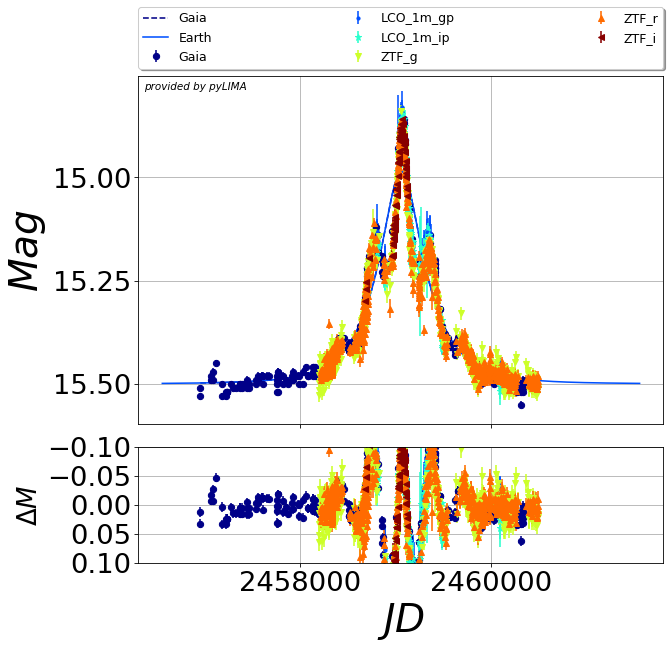

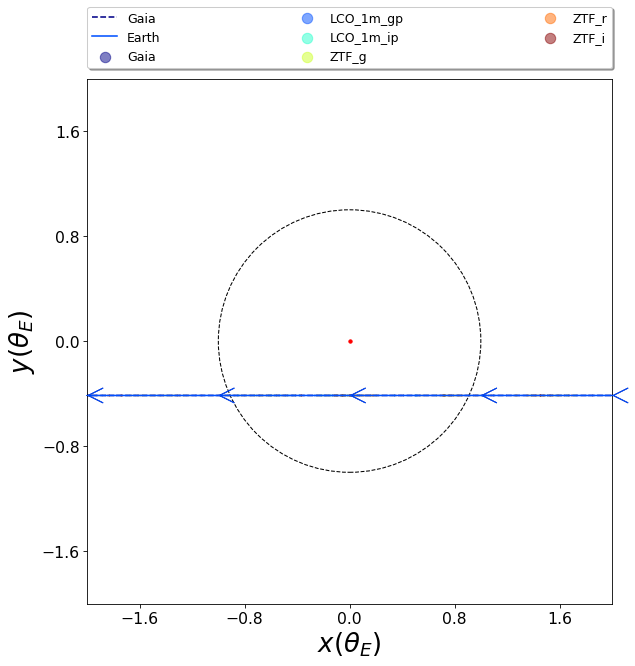

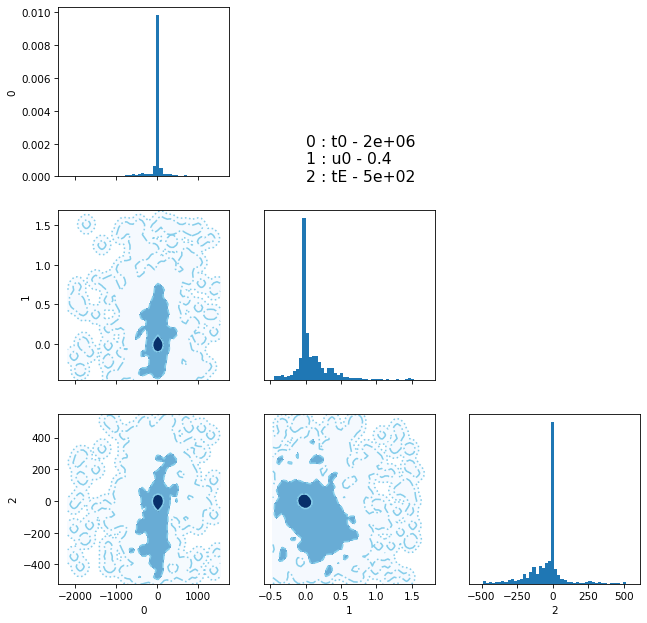

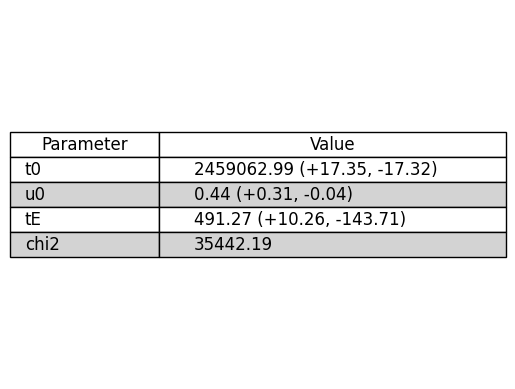

In [8]:
fit_init.fit_outputs(bokeh_plot=True)

Successfully ephemeris from JPL!
Parallax(Full) estimated for the telescope Gaia: SUCCESS
Parallax(Full) estimated for the telescope LCO_1m_gp: SUCCESS


(<Figure size 750x750 with 2 Axes>,
 <Figure size 750x750 with 1 Axes>,
 None,
 <Figure size 750x750 with 16 Axes>,
 <Figure size 640x480 with 1 Axes>,
 GridPlot(id='p1633', ...))

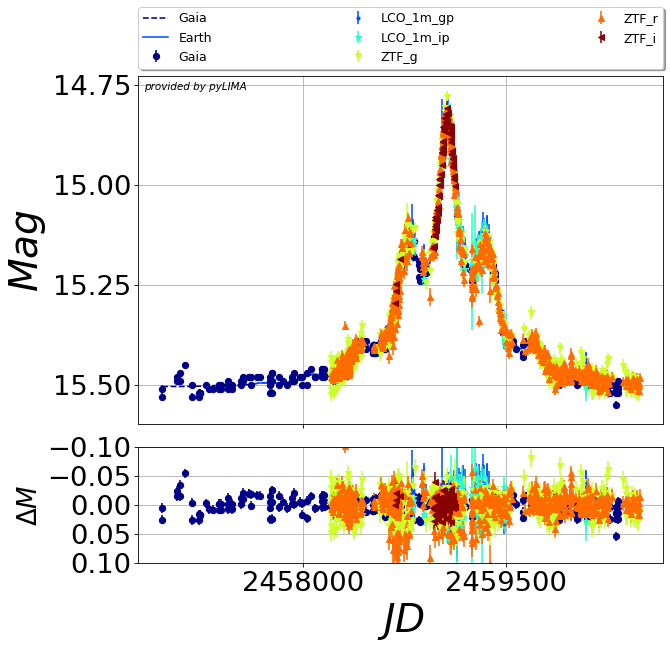

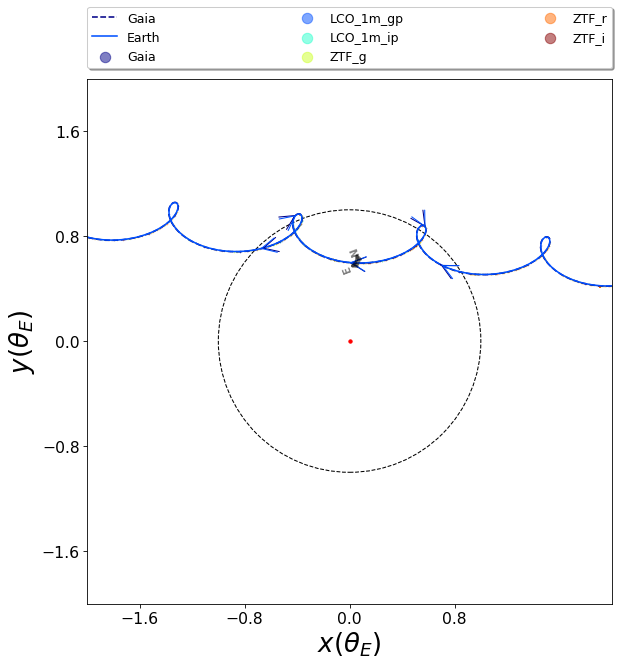

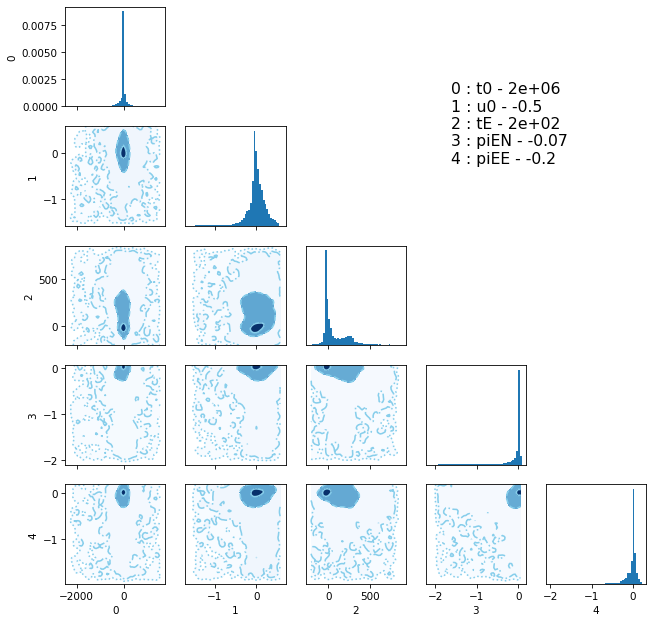

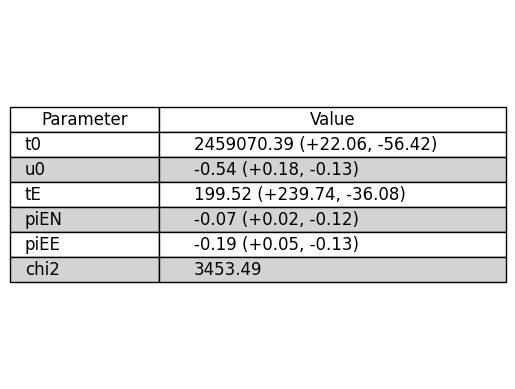

In [9]:
fit_par.fit_outputs()

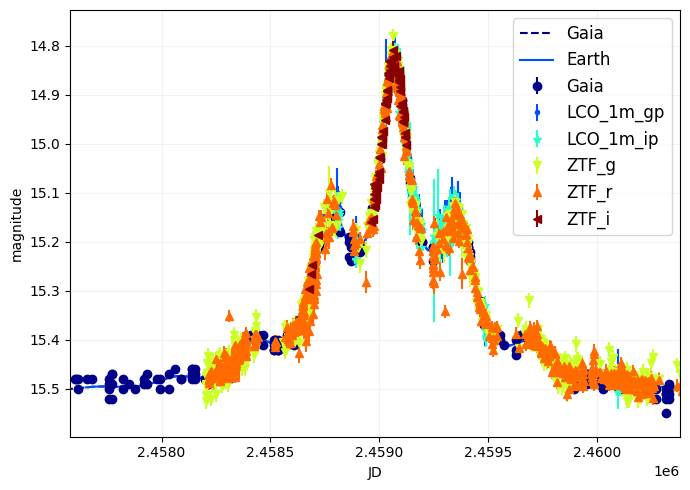

In [15]:
### Custom plots of 2 models
from pyLIMA.outputs import pyLIMA_plots
from cycler import cycler

# custom_cycler = (cycler(color=custom_color))

# pyLIMA_plots.MARKERS_COLORS = custom_cycler
# pyLIMA_plots.MARKER_SYMBOLS = np.array([custom_marker])

### Find the telescope fluxes if needed

if len(fit_init.fit_results['best_model']) != len(pspl_no_par.model_dictionnary):
    t_flux = pspl_no_par.find_telescopes_fluxes(fit_init.fit_results['best_model'])
    telescopes_fluxes = []
    # telescopes_fluxes = [getattr(telescopes_fluxes, key) for key in
    #                      telescopes_fluxes._fields]
    for key, value in t_flux.items():
        telescopes_fluxes.append(value)

    model_parameters1 = np.r_[fit_init.fit_results['best_model'], telescopes_fluxes]

else:
    
    model_parameters1 = fit_init.fit_results['best_model']

if len(fit_par.fit_results['best_model']) != len(pspl.model_dictionnary):
    t_flux = pspl.find_telescopes_fluxes(fit_par.fit_results['best_model'])
    telescopes_fluxes = []
    # telescopes_fluxes = [getattr(telescopes_fluxes, key) for key in
    #                      telescopes_fluxes._fields]
    for key, value in t_flux.items():
        telescopes_fluxes.append(value)

    model_parameters2 = np.r_[fit_par.fit_results['best_model'], telescopes_fluxes]

else:
    
    model_parameters2 = fit_par.fit_results['best_model']

# tmin, tmax = 2460200., data_ogle[-1,0]+5.
# tmin, tmax = 2460160., data_ogle[-1,0]+20.
# fig, axes = plt.subplots(2, 1, height_ratios=[3, 1])
fig, axes = plt.subplots(1, 1)
fig.set_figheight(5)
fig.set_figwidth(7)

tmin, tmax = 2457580., data_gsa[-1,0]+50.

# Lc plot
# axes[0].title.set_text(name)
# axes[0].set_ylabel("magnitude") 
# axes[0].grid(True, color='0.95')
# axes[0].invert_yaxis()
# axes.title.set_text(name)
axes.set_ylabel("magnitude") 
axes.grid(True, color='0.95')
axes.invert_yaxis()

axes.set_xlim(tmin, tmax) 
# axes[0].set_xlim(tmin, tmax) 
# axes[0].set_ylim(18.5, 12.5) 
# axes[0].set_ylim(17.5, 12.5) 

#Plot model1 and align data to it
# pyLIMA_plots.plot_photometric_models(axes[0], pspl, model_parameters2, plot_unit='Mag')
# # pyLIMA_plots.plot_photometric_models(axes[0], pspl_no_par, model_parameters1, plot_unit='Mag')
# pyLIMA_plots.plot_aligned_data(axes[0], pspl, model_parameters2, plot_unit='Mag')

pyLIMA_plots.plot_photometric_models(axes, pspl, model_parameters2, plot_unit='Mag')
# pyLIMA_plots.plot_photometric_models(axes[0], pspl_no_par, model_parameters1, plot_unit='Mag')
pyLIMA_plots.plot_aligned_data(axes, pspl, model_parameters2, plot_unit='Mag')
# axes[1].set_xlabel("JD")
axes.set_xlabel("JD")

# # plot residuals
# axes[1].set_ylabel("res") 
# axes[1].grid(True, color='0.95')
# # # axes[1].invert_yaxis()

# pyLIMA_plots.plot_residuals(axes[1], pspl, model_parameters2, plot_unit='Mag')
# # axes[1].set_xlim(tmin, tmax)
# axes[1].set_ylim(-0.12, 0.12)
# axes[1].axhline(y=0)

# axes[0].legend(shadow=True, fontsize='large',
#                           bbox_to_anchor=(0, 1.02, 1, 0.2),
#                           loc="lower left",
#                           mode="expand", borderaxespad=0, ncol=3)

axes.legend(shadow=False, fontsize='large',
                          # bbox_to_anchor=(0, 1.02, 1, 0.2),
                          loc="upper right", ncol=1)
                          # mode="expand", borderaxespad=0, )

# plt.savefig('OGLE-2023-BLG-1060_zoom_out.pdf', format='pdf')
# plt.savefig('OGLE-2023-BLG-1060_zoom_in.pdf', format='pdf')
plt.tight_layout()
plt.savefig('Gaia19dke_no_residuals.pdf', format='pdf')
plt.show()